In [6]:
# Install SHAP
import sys
import subprocess

print("Installing SHAP library...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "shap"])
print("Installation complete!")
print("\nPlease restart the kernel and run Cell 1 again.")

Installing SHAP library...
Installation complete!

Please restart the kernel and run Cell 1 again.


STEP 6: SHAP EXPLAINABILITY INTEGRATION
Started: 2026-02-26 02:07:03



Loading data and model...
  Training set: (35000, 25)
  Test set: (15000, 25)
  Model: Random_Forest

Creating SHAP explainer...
  Explainer created!

Calculating SHAP values (this may take 1-2 minutes)...
  Raw SHAP values type: <class 'numpy.ndarray'>
  SHAP values shape: (500, 25, 2)
  New shape: (500, 25)
  Shape validated: (500, 25)

GLOBAL FEATURE IMPORTANCE
  Mean SHAP shape: (25,)
  Feature names count: 25

Top 15 Features by SHAP Importance:
--------------------------------------------------------------------------------
  avg_payment_delay_days              0.0990
  employment_type_encoded             0.0953
  income_tier                         0.0798
  spending_volatility_cv              0.0749
  bill_payment_consistency            0.0511
  app_usage_regularity_days           0.0409
  education_level                     0.0340
  bounce_rate_txn                     0.0299
  savings_ratio                       0.0161
  ecommerce_txn_frequency             0.0122
  existing_loa

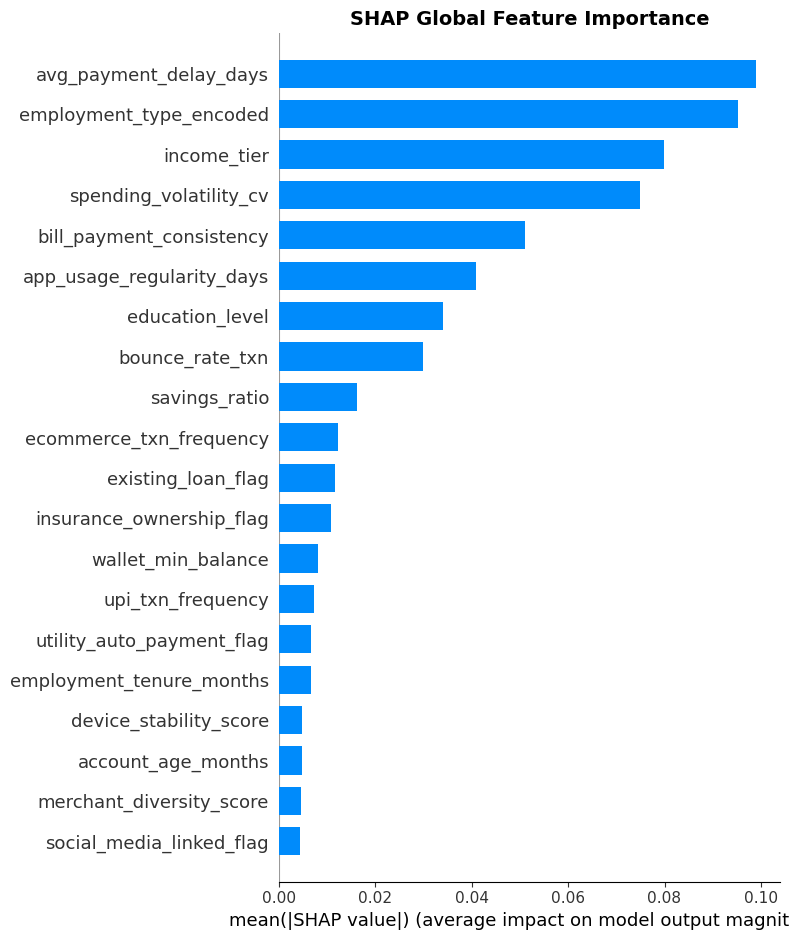

Saved: data/shap_summary_beeswarm.png


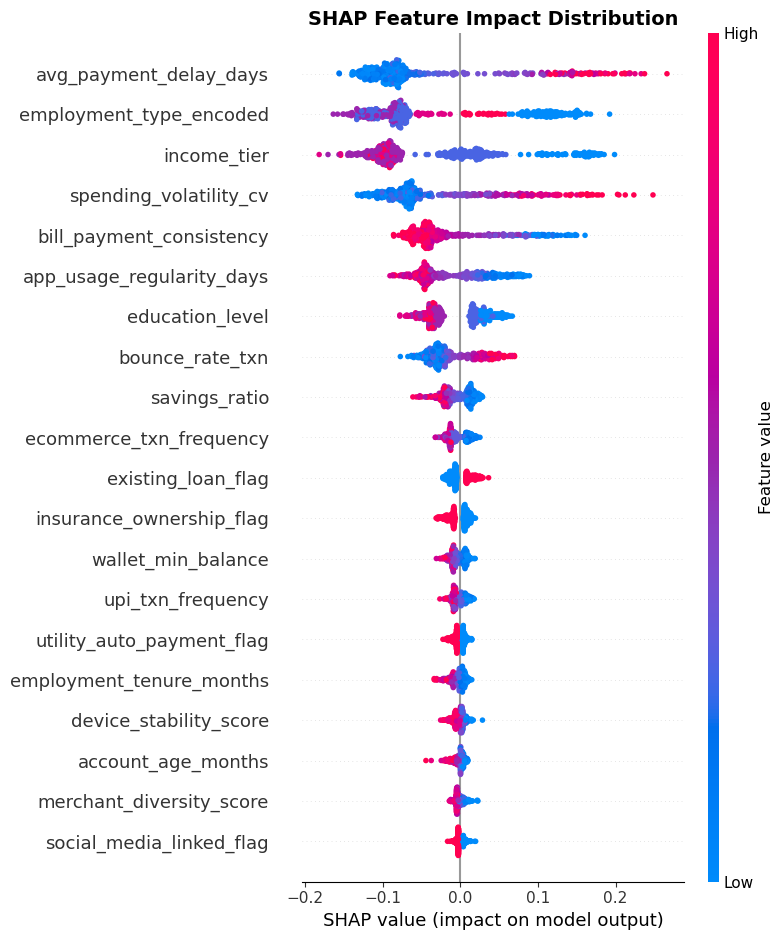


LOCAL EXPLAINABILITY - INDIVIDUAL PREDICTION

Sample #0:
  Predicted Probability: 1.24%
  Predicted Label: No Default

Top 10 Feature Contributions:
--------------------------------------------------------------------------------
Feature                             Value       SHAP Impact
--------------------------------------------------------------------------------
income_tier                          1.28    -0.1052  - Decreases risk
employment_type_encoded              0.65    -0.0869  - Decreases risk
avg_payment_delay_days              -0.36    -0.0733  - Decreases risk
spending_volatility_cv              -0.59    -0.0635  - Decreases risk
app_usage_regularity_days            1.41    -0.0502  - Decreases risk
education_level                      1.91    -0.0415  - Decreases risk
bounce_rate_txn                     -0.90    -0.0294  - Decreases risk
bill_payment_consistency             0.13    -0.0272  - Decreases risk
ecommerce_txn_frequency              0.70    -0.0140  - Decr

D:\Anaconda_download\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
D:\Anaconda_download\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Saved:
  - data/shap_global_importance.csv
  - data/shap_summary_bar.png
  - data/shap_summary_beeswarm.png
  - data/shap/shap_values.npy
  - data/shap/X_sample.csv
  - data/shap/shap_summary.txt

STEP 6 COMPLETE - SHAP EXPLAINABILITY

SUMMARY

Model Explained:        Random_Forest
Samples Analyzed:       500
Total Features:         25

Top 5 Important Features:
                 Feature  Mean_SHAP_Value
  avg_payment_delay_days         0.099007
 employment_type_encoded         0.095252
             income_tier         0.079837
  spending_volatility_cv         0.074853
bill_payment_consistency         0.051107

Status: ALL 6 STEPS COMPLETE!


Completed: 2026-02-26 02:07:43


In [ ]:
# ============================================================================
# STEP 6: SHAP EXPLAINABILITY - COMPLETE (FIXED)
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import os
from datetime import datetime

print("="*80)
print("STEP 6: SHAP EXPLAINABILITY INTEGRATION")
print("="*80)
print(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# Initialize SHAP
shap.initjs()

# ============================================================================
# LOAD DATA AND MODEL
# ============================================================================

print("Loading data and model...")

# Load data
X_train = pd.read_csv('data/preprocessed/X_train.csv')
X_test = pd.read_csv('data/preprocessed/X_test.csv')
y_test = pd.read_csv('data/preprocessed/y_test.csv').values.ravel()

print(f"  Training set: {X_train.shape}")
print(f"  Test set: {X_test.shape}")

# Get feature names
feature_names = X_test.columns.tolist()

# Load best model
best_model_path = None
for path in ['models/trained/Random_Forest.pkl', 'models/trained/Logistic_Regression.pkl', 'models/trained/XGBoost.pkl']:
    if os.path.exists(path):
        best_model_path = path
        break

best_model = joblib.load(best_model_path)
best_model_name = os.path.basename(best_model_path).replace('.pkl', '')
print(f"  Model: {best_model_name}")

# ============================================================================
# CREATE SHAP EXPLAINER
# ============================================================================

print("\nCreating SHAP explainer...")

background_size = min(100, len(X_train))
X_background = X_train.sample(n=background_size, random_state=42)

if best_model_name == 'Logistic_Regression':
    explainer = shap.LinearExplainer(best_model, X_background)
else:
    explainer = shap.TreeExplainer(best_model)

print("  Explainer created!")

# ============================================================================
# CALCULATE SHAP VALUES
# ============================================================================

print("\nCalculating SHAP values (this may take 1-2 minutes)...")

sample_size = min(500, len(X_test))
X_sample = X_test.sample(n=sample_size, random_state=42)

shap_values = explainer.shap_values(X_sample)

# FIX: Handle different SHAP value formats
print(f"  Raw SHAP values type: {type(shap_values)}")

if isinstance(shap_values, list):
    # Binary classification - take positive class
    shap_values = shap_values[1]
    print(f"  Extracted positive class SHAP values")

# Additional check for shape
print(f"  SHAP values shape: {shap_values.shape}")

# If 3D, flatten to 2D
if len(shap_values.shape) == 3:
    print(f"  WARNING: 3D array detected, reshaping...")
    shap_values = shap_values[:, :, 1]  # Take positive class
    print(f"  New shape: {shap_values.shape}")

# Final validation
if shap_values.shape[0] != sample_size:
    print(f"  ERROR: Shape mismatch!")
    print(f"    Expected samples: {sample_size}")
    print(f"    Got: {shap_values.shape[0]}")
else:
    print(f"  Shape validated: {shap_values.shape}")

# ============================================================================
# GLOBAL FEATURE IMPORTANCE
# ============================================================================

print("\n" + "="*80)
print("GLOBAL FEATURE IMPORTANCE")
print("="*80)

# Calculate mean absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)

print(f"  Mean SHAP shape: {mean_abs_shap.shape}")
print(f"  Feature names count: {len(feature_names)}")

# Ensure shapes match
if len(mean_abs_shap) != len(feature_names):
    print(f"  ERROR: Length mismatch!")
    print(f"    Mean SHAP: {len(mean_abs_shap)}")
    print(f"    Features: {len(feature_names)}")
    # Try to fix
    if len(mean_abs_shap.shape) > 1:
        mean_abs_shap = mean_abs_shap.flatten()
        print(f"    Flattened to: {mean_abs_shap.shape}")

# Create DataFrame
global_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_SHAP_Value': mean_abs_shap
}).sort_values('Mean_SHAP_Value', ascending=False)

print("\nTop 15 Features by SHAP Importance:")
print("-"*80)
for i, row in global_importance.iterrows():
    print(f"  {row['Feature']:<35} {row['Mean_SHAP_Value']:.4f}")

# Save
os.makedirs('data', exist_ok=True)
global_importance.to_csv('data/shap_global_importance.csv', index=False)
print("\nSaved: data/shap_global_importance.csv")

# ============================================================================
# SHAP SUMMARY PLOT - BAR
# ============================================================================

print("\n" + "="*80)
print("SHAP SUMMARY PLOTS")
print("="*80)

try:
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, plot_type="bar", show=False)
    plt.title("SHAP Global Feature Importance", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/shap_summary_bar.png', dpi=300, bbox_inches='tight')
    print("Saved: data/shap_summary_bar.png")
    plt.show()
except Exception as e:
    print(f"Bar plot error: {e}")

# ============================================================================
# SHAP SUMMARY PLOT - BEESWARM
# ============================================================================

try:
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_names, show=False)
    plt.title("SHAP Feature Impact Distribution", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('data/shap_summary_beeswarm.png', dpi=300, bbox_inches='tight')
    print("Saved: data/shap_summary_beeswarm.png")
    plt.show()
except Exception as e:
    print(f"Beeswarm plot error: {e}")

# ============================================================================
# LOCAL EXPLANATION - SINGLE PREDICTION
# ============================================================================

print("\n" + "="*80)
print("LOCAL EXPLAINABILITY - INDIVIDUAL PREDICTION")
print("="*80)

sample_idx = 0
sample_data = X_sample.iloc[sample_idx]
sample_shap = shap_values[sample_idx]

pred_proba = best_model.predict_proba(sample_data.values.reshape(1, -1))[0][1]
pred_label = best_model.predict(sample_data.values.reshape(1, -1))[0]

print(f"\nSample #{sample_idx}:")
print(f"  Predicted Probability: {pred_proba:.2%}")
print(f"  Predicted Label: {'Default' if pred_label == 1 else 'No Default'}")

# Top contributors
contributions = list(zip(feature_names, sample_shap, sample_data.values))
contributions.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nTop 10 Feature Contributions:")
print("-"*80)
print(f"{'Feature':<30} {'Value':>10} {'SHAP':>10} {'Impact'}")
print("-"*80)

for feat_name, shap_val, feat_val in contributions[:10]:
    direction = "Increases" if shap_val > 0 else "Decreases"
    arrow = "+" if shap_val > 0 else "-"
    print(f"{feat_name:<30} {feat_val:>10.2f} {shap_val:>+10.4f}  {arrow} {direction} risk")

# ============================================================================
# SAVE RESULTS
# ============================================================================

print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

os.makedirs('data/shap', exist_ok=True)

np.save('data/shap/shap_values.npy', shap_values)
X_sample.to_csv('data/shap/X_sample.csv', index=False)

with open('data/shap/shap_summary.txt', 'w') as f:
    f.write("SHAP EXPLAINABILITY SUMMARY\n")
    f.write("="*80 + "\n\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Model: {best_model_name}\n")
    f.write(f"Samples Explained: {sample_size}\n\n")
    f.write("Top 10 Features:\n")
    f.write(global_importance.to_string(index=False))

print("Saved:")
print("  - data/shap_global_importance.csv")
print("  - data/shap_summary_bar.png")
print("  - data/shap_summary_beeswarm.png")
print("  - data/shap/shap_values.npy")
print("  - data/shap/X_sample.csv")
print("  - data/shap/shap_summary.txt")

# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("STEP 6 COMPLETE - SHAP EXPLAINABILITY")
print("="*80)

print(f"""
SUMMARY
{'='*80}

Model Explained:        {best_model_name}
Samples Analyzed:       {sample_size}
Total Features:         {len(feature_names)}

Top 5 Important Features:
{global_importance.head(5).to_string(index=False)}

Status: ALL 6 STEPS COMPLETE!
""")

print(f"\nCompleted: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")